# Instacart Customer Analytics - Data Exploration

# 1.Setup

In [70]:
import duckdb
import pandas as pd
import plotly.express as px
# Create DuckDB connection
con = duckdb.connect()


In [39]:
# Paths
DATA_DIR = '../data'
OUTPUT_DIR = '../data/processed_data'

# Load CSVs into pandas dataframes
orders = pd.read_csv(f'{DATA_DIR}/orders.csv')
products = pd.read_csv(f'{DATA_DIR}/products.csv')
departments = pd.read_csv(f'{DATA_DIR}/departments.csv')
aisles = pd.read_csv(f'{DATA_DIR}/aisles.csv')
order_products = pd.read_csv(f'{DATA_DIR}/order_products__prior.csv')

In [40]:
# Register dataframes with DuckDB for SQL queries
con.register('orders', orders)
con.register('products', products)
con.register('departments', departments)
con.register('aisles', aisles)
con.register('order_products', order_products)

In [7]:
# Summary
print(f"   - {len(orders):,} orders")
print(f"   - {len(products):,} products")
print(f"   - {len(departments)} departments")
print(f"   - {len(aisles)} aisles")
print(f"   - {len(order_products):,} order-product records")
print(f"   - {orders['user_id'].nunique():,} unique customers")

   - 3,421,083 orders
   - 49,688 products
   - 21 departments
   - 134 aisles
   - 32,434,489 order-product records
   - 206,209 unique customers


# 2.Cleaning

In [ ]:
# checking data quality

# Check for nulls
print("Missing values:")
print(orders.isnull().sum())
print(products.isnull().sum())
print()

# Check data types
print("Data types:")
print(orders.dtypes)
print()

# Check for invalid values
print(f"Invalid day of week (should be 0-6): {(orders['order_dow'] > 6).sum()}")
print(f"Invalid hour (should be 0-23): {(orders['order_hour_of_day'] > 23).sum()}")
print(f"Negative order numbers: {(orders['order_number'] < 0).sum()}")

No missing values in critical fields (order_id, user_id, product_id)
All temporal fields (day, hour) within valid ranges
No negative values in numeric fields

In [15]:
# Proportion of products in missing department
missing_dept = (
    order_products
    .merge(products, on='product_id')
    .merge(departments, on='department_id')
)
missing_count = (missing_dept['department'] == 'missing').sum()
missing_pct = (missing_count / len(missing_dept)) * 100

print(f"Missing department: {missing_count:,} records ({missing_pct:.2f}%)")

Missing department: 69,145 records (0.21%)


These are excluded from department-specific analyses only.

# Exploratory Analysis

In [16]:
order_query = """
SELECT *
FROM orders
LIMIT 5
"""

orders_sample = con.execute(order_query).df()
print(f"Orders shape: {orders_sample.shape}")
orders_sample

Orders shape: (5, 7)


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [17]:
# explore products dataset
products_query = """
SELECT *
FROM products
LIMIT 5
"""

products_sample = con.execute(products_query).df()
products_sample

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [18]:
# explore aisles dataset
aisles_query = """
SELECT *
FROM aisles
LIMIT 5
"""

aisles_sample = con.execute(aisles_query).df()
aisles_sample

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [19]:
# explore departments
departments_query = """
SELECT *
FROM departments
LIMIT 5
"""

departments_sample = con.execute(departments_query).df()
departments_sample

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [31]:
# seeing what is in order products prior
order_products_prior_query = """
SELECT *
FROM order_products
LIMIT 10
"""

products_prior = con.execute(order_products_prior_query).df()
products_prior

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0
5,2,17794,6,1
6,2,40141,7,1
7,2,1819,8,1
8,2,43668,9,0
9,3,33754,1,1


In [20]:
# get orders count
order_count = " SELECT COUNT(*) as count FROM orders"
orders_c = con.execute(order_count).df()['count'][0]
print(orders_c)

3421083


There are 3.4 million orders in the order csv.

In [33]:
# calculating average basket size (number of items per order)
# count number of products per order then average it
average_basket_query = """
SELECT AVG(product_count) as average_basket
FROM (
    SELECT COUNT(*) as product_count, order_id
    FROM order_products
    GROUP BY order_id)
"""

average_basket = con.execute(average_basket_query).df()['average_basket'][0]
print(f"Average basket size is {average_basket}")

Average basket size is 10.088883421247614


In [55]:
# Distribution of customers by order amount 
user_orders_query = """
SELECT 
    MAX(order_number) as max_orders,
    COUNT(*) as num_customers
FROM orders
GROUP BY user_id
ORDER BY max_orders
"""

user_dist = con.execute(user_orders_query).df()

print(user_dist.describe())
print("\nCustomers with 10+ orders:", 
      user_dist[user_dist['max_orders'] >= 10].shape[0])
print("Customers with 15+ orders:", 
      user_dist[user_dist['max_orders'] >= 15].shape[0])
print("Customers with 20+ orders:", 
      user_dist[user_dist['max_orders'] >= 20].shape[0])



          max_orders  num_customers
count  206209.000000  206209.000000
mean       16.590367      16.590367
std        16.654774      16.654774
min         4.000000       4.000000
25%         6.000000       6.000000
50%        10.000000      10.000000
75%        20.000000      20.000000
max       100.000000     100.000000

Customers with 10+ orders: 110728
Customers with 15+ orders: 75080
Customers with 20+ orders: 53931


## 3.1 Temporal Patterns

In [37]:
# ordering behaviour across days of the week
orders_daily_query = """
SELECT 
    order_dow as day_of_week,
    COUNT(*) as num_orders,
    COUNT(DISTINCT user_id) as unique_users,
    AVG(days_since_prior_order) as avg_days_between_orders
FROM read_csv_auto('../data/orders.csv')
WHERE days_since_prior_order IS NOT NULL
GROUP BY order_dow
ORDER BY order_dow
"""

order_trends = con.execute(orders_daily_query).df()
order_trends

Shape: (7, 4)


,day_of_week,num_orders,unique_users,avg_days_between_orders
0,0,562388,145979,11.773868
1,1,552505,150965,11.311552
2,2,439399,139601,11.169766
3,3,411314,134859,10.768301
4,4,401903,132307,10.522935
5,5,427295,133821,10.508295
6,6,420070,128717,11.438924


Most orders are being placed on Sunday and with a steady decrease throughout the week. Typically 10-11 average days between orders

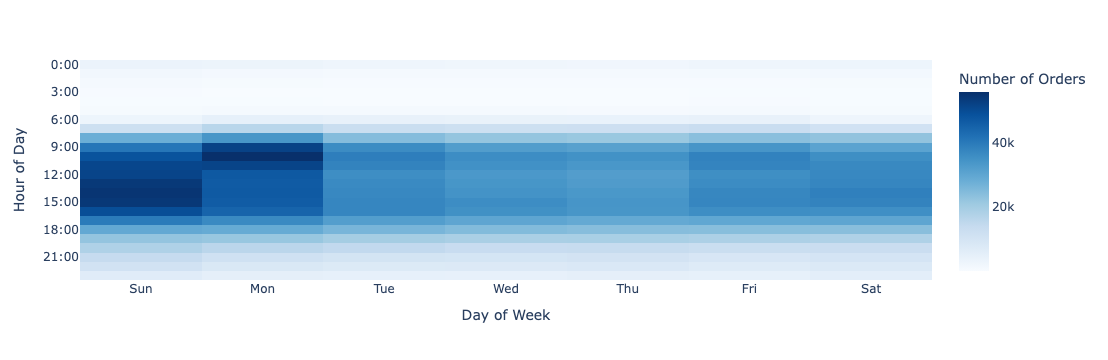

In [41]:
# Orders by hour of day as percentages
order_hour_query = """
SELECT
    order_dow as day,
    order_hour_of_day as order_hour,
    COUNT(*) as orders,
    ROUND( COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) as percentage_hour,
    ROUND( SUM (COUNT(*)) OVER(PARTITION BY order_dow)  * 100.0 / SUM(COUNT(*)) OVER(), 2) as percentage_day
FROM orders
GROUP BY order_hour, day
ORDER BY day, order_hour
"""

days_hours_df = con.execute(order_hour_query).df()

heatmap_matrix = days_hours_df.pivot(index='order_hour', columns='day', values='orders')

fig_heatmap = px.imshow(
        heatmap_matrix,
        labels=dict(x="Day of Week", y="Hour of Day",
                    color="Number of Orders"),
        x=['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat'],
        color_continuous_scale='Blues'
    )

fig_heatmap.update_yaxes(
    tickmode='array',
    tickvals=list(range(0, 24, 3)),
    ticktext=[f'{h}:00' for h in range(0, 24, 3)],
    autorange='reversed'
)

fig_heatmap.show()

10am-4pm is when most orders take place

In [45]:
# Basket size analysis - average items per order by day/hour
basket_size_days_query = """
SELECT 
    AVG(product_count) as average_basket,
    order_dow as days
FROM (
    SELECT COUNT(*) as product_count, order_id
    FROM order_products
    GROUP BY order_id) order_products
INNER JOIN orders
    ON order_products.order_id = orders.order_id
GROUP BY days
ORDER BY days
"""

basket_size_days = con.execute(basket_size_days_query).df()
basket_size_days

,average_basket,days
0,11.132983,0
1,10.177484,1
2,9.543501,2
3,9.321331,3
4,9.439436,4
5,9.881950,5
6,10.744480,6


## 3.2 Product Analysis

In [60]:
# Finding top products by order quantity
popular_products_query = """
SELECT
    product_name,
    departments.department,
    COUNT (*) as product_count,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) as pct_of_total
FROM order_products order_products
INNER JOIN products products
    ON order_products.product_id = products.product_id
INNER JOIN departments departments
    ON products.department_id = departments.department_id

GROUP BY product_name, departments.department
ORDER BY product_count DESC
LIMIT 20
"""

popular_products = con.execute(popular_products_query).df()

popular_products

,product_name,department,product_count,pct_of_total
0,Banana,produce,472565,1.46
1,Bag of Organic Bananas,produce,379450,1.17
2,Organic Strawberries,produce,264683,0.82
3,Organic Baby Spinach,produce,241921,0.75
4,Organic Hass Avocado,produce,213584,0.66
5,Organic Avocado,produce,176815,0.55
6,Large Lemon,produce,152657,0.47
7,Strawberries,produce,142951,0.44
8,Limes,produce,140627,0.43
9,Organic Whole Milk,dairy eggs,137905,0.43


From top 20 products, we can see that majority of products are produce and also organic

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

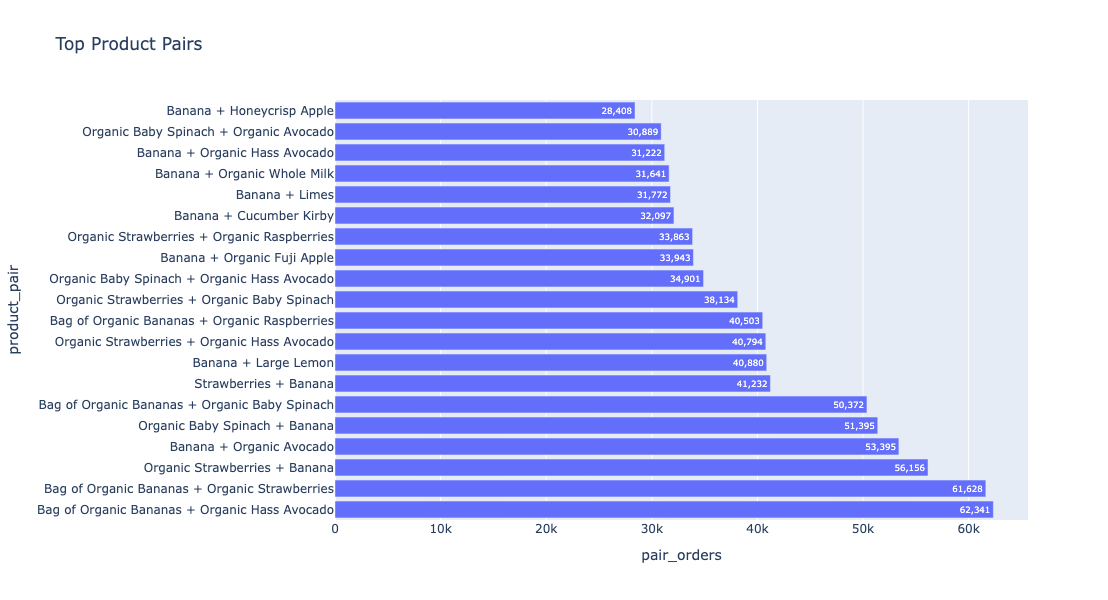

In [71]:
# Top product pairs for same order
product_pairs_query = """
SELECT
    prod1.product_name as p1,
    prod2.product_name as p2,
    COUNT (*) as pair_orders
FROM order_products
INNER JOIN order_products order_products_2
    ON order_products.order_id = order_products_2.order_id
    AND order_products.product_id < order_products_2.product_id
INNER JOIN products prod1
    ON order_products.product_id = prod1.product_id
INNER JOIN products prod2
    ON order_products_2.product_id = prod2.product_id
GROUP BY p1, p2
ORDER BY pair_orders DESC
LIMIT 20
"""

product_pairs_df = con.execute(product_pairs_query).df()
product_pairs_df.to_csv('../data/processed_data/top_product_pairs.csv', index = False)

# Bar Chart of top product pairs
# making new variable of the specific product pair
product_pairs_df['product_pair'] = product_pairs_df['p1'] + ' + ' + product_pairs_df['p2']

fig = px.bar(
    product_pairs_df,
    x='pair_orders',
    y='product_pair',
    orientation='h',
    title='Top Product Pairs',
    text='pair_orders'
)

fig.update_traces(texttemplate='%{text:,}')
fig.update_layout(height=600)

fig.show()
    

## 3.3 Loyalty/ Reorder Analysis

In [35]:
# Repeat order rate
reorder_query = """
SELECT AVG(reordered) as reorder_rate
FROM order_products
"""

reordered = con.execute(reorder_query).df()['reorder_rate'][0]
print(f"Reorder rate is {reordered}")

Reorder rate is 0.5896974667922161


In [64]:
# How reorder rate changes as the customer makes more orders
loyalty_growth_query = """
SELECT 
    o.order_number,
    ROUND(AVG(op.reordered) * 100, 2) as reorder_rate_pct,
    COUNT(*) as num_items,
    COUNT(DISTINCT o.order_id) as num_orders,
    COUNT(DISTINCT o.user_id) as num_customers
FROM orders o
INNER JOIN order_products op
    ON o.order_id = op.order_id
WHERE o.order_number <= 20
GROUP BY o.order_number
ORDER BY o.order_number
"""

loyalty_growth = con.execute(loyalty_growth_query).df()
print(loyalty_growth)

    order_number  reorder_rate_pct  num_items  num_orders  num_customers
0              1              0.00    2078068      206209         206209
1              2             27.24    2048332      206209         206209
2              3             38.63    2050731      206209         206209
3              4             45.83    1820298      182223         182223
4              5             50.74    1628411      162633         162633
5              6             54.51    1472238      146468         146468
6              7             57.59    1333847      132618         132618
7              8             59.90    1219148      120918         120918
8              9             62.01    1120468      110728         110728
9             10             63.66    1028704      101696         101696
10            11             65.22     950655       93881          93881
11            12             66.77     877632       86929          86929
12            13             67.80     819712      

## 3.4 Department Analysis

In [72]:
# products ordered by department they belong to 
dept_prod_orders_query = """
SELECT 
    d.department,
    COUNT (*) as products_ordered
FROM order_products op
INNER JOIN products p
ON op.product_id = p.product_id
INNER JOIN departments d
ON d.department_id = p.department_id
WHERE d.department != 'missing'
GROUP BY d.department
ORDER BY products_ordered
"""

dept_orders = con.execute(dept_prod_orders_query).df()



In [73]:
# Average basket size is computed as the total number of items in an order, conditioned on the presence of at least one product from a given department
dept_analysis_query = """
SELECT
    d.department,
    COUNT(DISTINCT p.product_id) as products_included,
    COUNT(*) as order_count,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) as pct_of_all_orders,
    SUM(CASE WHEN op.reordered = 1 THEN 1 ELSE 0 END) as num_reorders,
    ROUND(SUM(CASE WHEN op.reordered = 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as reorder_rate_pct,
    ROUND(AVG(basket_sizes.basket_size), 2) as avg_basket_size,
    ROUND(AVG(o.days_since_prior_order), 2) as avg_days_between_orders
FROM order_products op
INNER JOIN products p
    ON op.product_id = p.product_id
INNER JOIN departments d
    ON p.department_id = d.department_id
INNER JOIN (
    -- Subquery: basket size for each order
    SELECT order_id, COUNT(*) as basket_size
    FROM order_products
    GROUP BY order_id
) basket_sizes
    ON op.order_id = basket_sizes.order_id
INNER JOIN orders o
    ON op.order_id = o.order_id
WHERE d.department != 'missing'
GROUP BY d.department
ORDER BY avg_days_between_orders DESC
"""

dept_df = con.execute(dept_analysis_query).df()
dept_df.head()


,department,products_included,order_count,pct_of_all_orders,num_reorders,reorder_rate_pct,avg_basket_size,avg_days_between_orders
0,household,3083,738666,2.28,297075.0,40.22,14.51,12.00
1,pets,972,97724,0.30,58760.0,60.13,15.19,11.87
2,dry goods pasta,1858,866627,2.68,399581.0,46.11,17.33,11.77
3,frozen,4007,2236432,6.91,1211890.0,54.19,16.11,11.73
4,canned goods,2092,1068058,3.30,488535.0,45.74,17.22,11.66


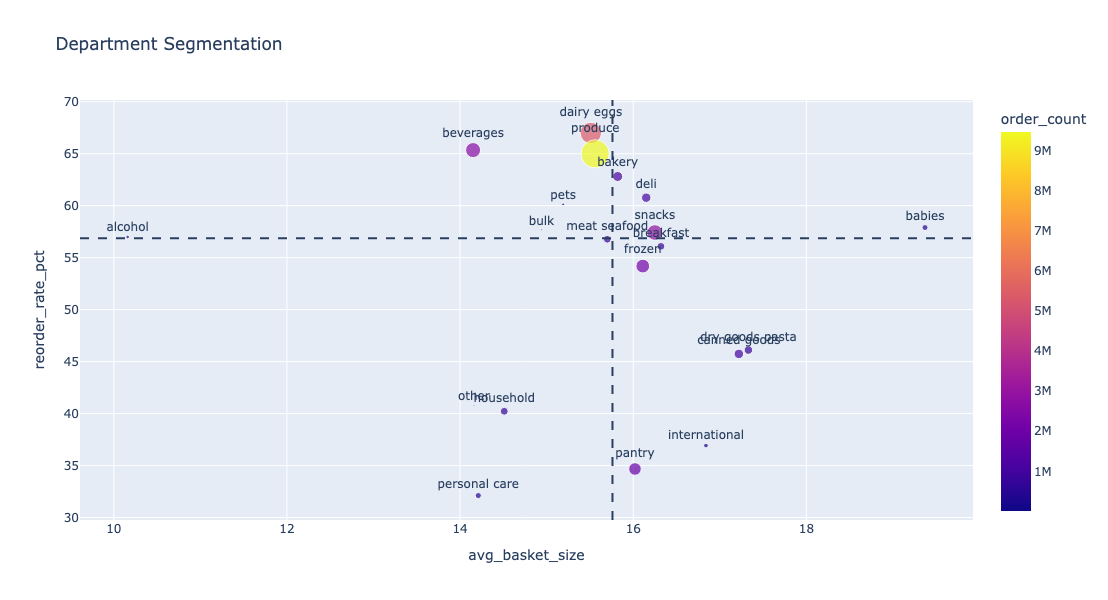

In [74]:
# Quick scatter plot
fig = px.scatter(
    dept_df,
    x='avg_basket_size',
    y='reorder_rate_pct',
    size='order_count',
    color='order_count',
    hover_name='department',
    text='department',
    title='Department Segmentation'
)

# Add median lines
fig.add_vline(x=dept_df['avg_basket_size'].median(), line_dash="dash")
fig.add_hline(y=dept_df['reorder_rate_pct'].median(), line_dash="dash")

fig.update_traces(textposition='top center')
fig.update_layout(height=600)

fig.show()

In [75]:
# Sort by this column to see extremes
dept_df.sort_values('avg_days_between_orders')[['department', 'avg_days_between_orders']]

,department,avg_days_between_orders
19,babies,10.00
18,bulk,10.10
17,alcohol,10.34
16,produce,10.86
15,snacks,10.95
14,other,10.95
13,dairy eggs,10.99
12,beverages,11.05
11,bakery,11.10
10,pantry,11.16


In [76]:
# Concentration of department in each order on average
dept_conc_query = """
WITH order_totals as (
    SELECT
        order_id,
        COUNT (*) as product_total
    FROM order_products
    GROUP BY order_id
    ORDER BY order_id
),

dept_order_totals AS(
    SELECT
        op.order_id,
        d.department as department,
        COUNT (*) as department_count
    FROM order_products op
    INNER JOIN products p
        ON op.product_id = p.product_id
    INNER JOIN departments d
        ON p.department_id = d.department_id
    GROUP BY op.order_id, department
),

repeat_customers AS(
    SELECT
        user_id
    FROM orders
    GROUP BY user_id
    HAVING MAX(order_number) >= 15
)

SELECT
    dt.department,
    ROUND (AVG((dt.department_count)/ot.product_total)*100) as avg_dept_conc

FROM order_totals ot
INNER JOIN dept_order_totals dt
ON ot.order_id = dt.order_id
INNER JOIN orders o
ON o.order_id = ot.order_id
INNER JOIN repeat_customers rc
ON o.user_id = rc.user_id
WHERE dt.department != 'missing'
GROUP BY dt.department
ORDER BY avg_dept_conc ASC
"""

dept_conc = con.execute(dept_conc_query).df()
dept_conc

,department,avg_dept_conc
0,bulk,11.0
1,international,11.0
2,other,12.0
3,meat seafood,12.0
4,dry goods pasta,12.0
5,deli,13.0
6,bakery,13.0
7,canned goods,13.0
8,breakfast,13.0
9,personal care,16.0


The above analysis looks at the average concentration of the department in baskets where there is a product from the department, ie. provided there is a product from the baby department in the basket, what percentage of the basket do baby products typically take up. The analysis above is limited to customers hwich have made over 15 orders in order to understand repeat customer behaviour better and avoid analysis which is affected by customers who have one off orders concentrated in one department.

In [78]:
# Reorder rate by department, looks at reorders as a percentage of the department's total orders

reorders_departments_query = """
SELECT
    COUNT (DISTINCT products.product_id) as products_included,
    SUM(CASE WHEN order_products.reordered = 1 THEN 1 ELSE 0 END) as num_reorders,
    ROUND(SUM(CASE WHEN order_products.reordered = 1 THEN 1 ELSE 0 END)  * 100.0 / COUNT (*), 2) as reorder_rate_pct,
    departments.department,
    COUNT (*) as order_count,
    ROUND(COUNT(*) *100.0 / SUM(COUNT(*)) OVER(),2) as percentage_of_all_orders
FROM order_products order_products
INNER JOIN products products
    ON order_products.product_id = products.product_id
INNER JOIN departments departments
    ON products.department_id = departments.department_id
WHERE departments.department != 'missing'
GROUP BY departments.department
ORDER BY reorder_rate_pct DESC
"""

reorders_dept = con.execute(reorders_departments_query).df()
reorders_dept

,products_included,num_reorders,reorder_rate_pct,department,order_count,percentage_of_all_orders
0,3448,3627221.0,67.00,dairy eggs,5414016,16.73
1,4363,1757892.0,65.35,beverages,2690129,8.31
2,1684,6160710.0,64.99,produce,9479291,29.29
3,1516,739188.0,62.81,bakery,1176787,3.64
4,1322,638864.0,60.77,deli,1051249,3.25
5,972,58760.0,60.13,pets,97724,0.30
6,1081,245369.0,57.90,babies,423802,1.31
7,38,19950.0,57.70,bulk,34573,0.11
8,6263,1657973.0,57.42,snacks,2887550,8.92
9,1054,87595.0,56.99,alcohol,153696,0.47


### Department Purchase Concentration

Tracks how much of each order is devoted to a specific department as customers
make repeated purchases in that category. Helps identify if customers become
more or less focused on certain departments over time.

In [79]:
# Concentration of department in each order on average TRACKING CUSTOMER OVER ORDER LIFECYCLE only including orders where that department shows up
dept_conc_extension_query = """
WITH order_totals as (
    SELECT
        order_id,
        COUNT (*) as product_total
    FROM order_products
    GROUP BY order_id
    ORDER BY order_id
),

dept_order_totals AS(
    SELECT
        op.order_id,
        d.department as department,
        COUNT (*) as department_count
    FROM order_products op
    INNER JOIN products p
        ON op.product_id = p.product_id
    INNER JOIN departments d
        ON p.department_id = d.department_id
    GROUP BY op.order_id, department
),

dept_purchase_sequence AS (
    SELECT
        o.user_id,
        o.order_id,
        dt.department,
        dt.department_count,
        ot.product_total,
        ROW_NUMBER() OVER (
            PARTITION BY o.user_id, dt.department 
            ORDER BY o.order_number
        ) as dept_purchase_number
    FROM dept_order_totals dt
    INNER JOIN order_totals ot 
        ON dt.order_id = ot.order_id
    INNER JOIN orders o
        ON o.order_id = dt.order_id
),

repeat_dept_buyers AS(
    SELECT
        user_id,
        department
    FROM dept_purchase_sequence
    GROUP BY user_id, department
    HAVING COUNT(*) >= 5
)

SELECT
    dps.department,
    dps.dept_purchase_number,
    ROUND(AVG(dps.department_count * 100.0 / dps.product_total), 2) as avg_concentration_pct,
    COUNT(*) as num_purchases,
    COUNT(DISTINCT dps.user_id) as num_customers
FROM dept_purchase_sequence dps
INNER JOIN repeat_dept_buyers rdb
    ON dps.user_id = rdb.user_id 
    AND dps.department = rdb.department
WHERE dps.department != 'missing'
GROUP BY dps.department, dps.dept_purchase_number
HAVING COUNT(*) >= 30  -- Enough data points
ORDER BY dps.department, dps.dept_purchase_number
"""

dept_conc_adv = con.execute(dept_conc_extension_query).df()
dept_conc_adv

,department,dept_purchase_number,avg_concentration_pct,num_purchases,num_customers
0,alcohol,1,33.28,4915,4915
1,alcohol,2,33.71,4915,4915
2,alcohol,3,33.09,4915,4915
3,alcohol,4,33.68,4915,4915
4,alcohol,5,33.40,4915,4915
...,...,...,...,...,...
1333,snacks,82,25.97,64,64
1334,snacks,83,29.65,56,56
1335,snacks,84,26.28,51,51
1336,snacks,85,29.05,40,40


# Exports

In [80]:
days_hours_df.to_csv(f'{OUTPUT_DIR}/days_hours.csv', index=False)
popular_products.to_csv(f'{OUTPUT_DIR}/popular_products.csv', index = False)
loyalty_growth.to_csv(f'{OUTPUT_DIR}/loyalty_growth.csv', index=False)

In [81]:
dept_orders.to_csv(f'{OUTPUT_DIR}/dept_orders.csv', index = False)
dept_df.to_csv(f'{OUTPUT_DIR}/dept_data.csv', index = False)
dept_conc.to_csv(f'{OUTPUT_DIR}/dept_conc_simple.csv', index = False)
dept_conc_adv.to_csv(f'{OUTPUT_DIR}/lifecycle_concentration.csv', index = False)